# Tutorial pyOSRD #4
GROOT means Graph Representation Of Occupancies Timetables

In [16]:
from pyosrd import OSRD
from pyosrd.groot import from_sim

In [17]:
simulation='cvg_dvg'
sim = OSRD(simulation=simulation, dir='tmp')

[11:22:50,429] [INFO]  [StandaloneSimulationCommand] Loading infra: tmp/infra.json
[11:22:50,468] [INFO]              [FullInfra] parsing infra
[11:22:50,468] [INFO]              [FullInfra] adaptation to kotlin
[11:22:50,521] [INFO]              [FullInfra] loading signals
[11:22:50,523] [INFO]              [FullInfra] building blocks
[11:22:50,550] [INFO]  [StandaloneSimulationCommand] Loading input: tmp/simulation.json
[11:22:50,739] [INFO]  [StandaloneSimulationCommand] Running simulation for schedule group: group.2
[11:22:50,856] [DEBUG]             [Allowance] computing range n°1
[11:22:50,859] [DEBUG]             [Allowance]   computing section n°1
[11:22:50,859] [DEBUG]             [Allowance]   target time = 126.06939555
[11:22:50,859] [DEBUG]             [Allowance]     starting attempt 1
[11:22:50,862] [DEBUG]             [Allowance]     envelope time 183.993422
[11:22:50,862] [DEBUG]             [Allowance]     starting attempt 2
[11:22:50,862] [DEBUG]             [Allowanc

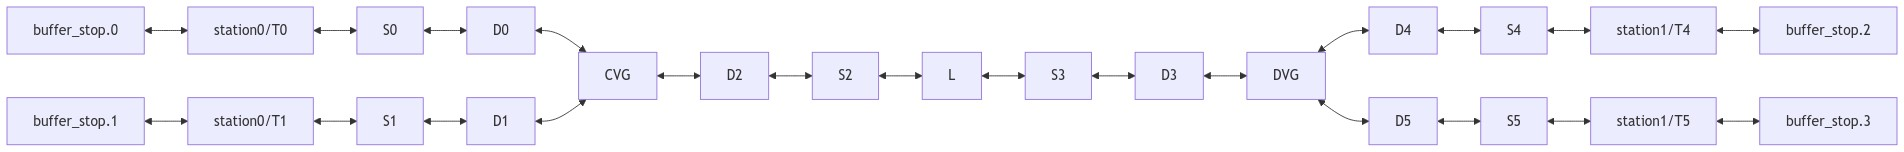

In [18]:
sim.draw_infra_points()

In [19]:
print(f"{sim.num_stations=}")
print(f"{sim.trains=}")
print(f"{sim.num_trains=}")

sim.num_stations=2
sim.trains=['train0', 'train1']
sim.num_trains=2


In [20]:
sim.space_time_chart_plotly(0, points_to_show=['switch','station', 'signal'], eco_or_base='eco')

In [21]:
groot = from_sim(sim)

In [22]:
groot.to_df()

train0                  train1            
                     s           e           s           e
station0/T0   0.000000   51.508421         NaN         NaN
CVG          26.438273   56.061499  126.436821  156.058421
D2<->D3      34.364029  100.845875  134.362142  201.502419
station0/T1        NaN         NaN  100.000000  151.505593
DVG          76.959499  112.972542  176.998681  214.325316
station1/T4  81.756343  125.517369         NaN         NaN
station1/T5        NaN         NaN  181.969403  225.127213

<Axes: xlabel='Time'>

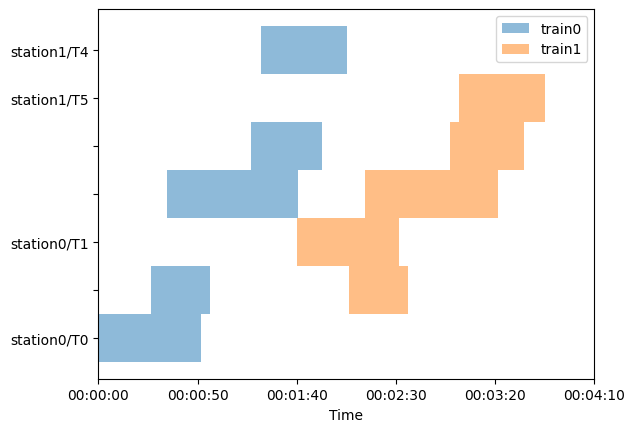

In [23]:
groot.plot()

<Axes: xlabel='Time'>

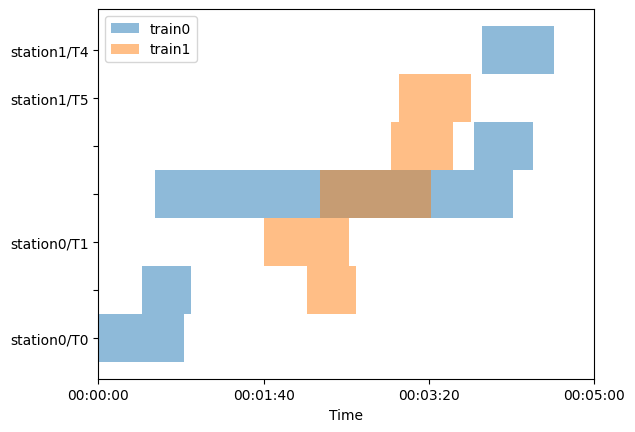

In [24]:
delayed_groot = groot.add_delay('train0', 'D2<->D3', 150)
delayed_groot.plot()

<Axes: title={'center': 'train0'}, xlabel='Time'>

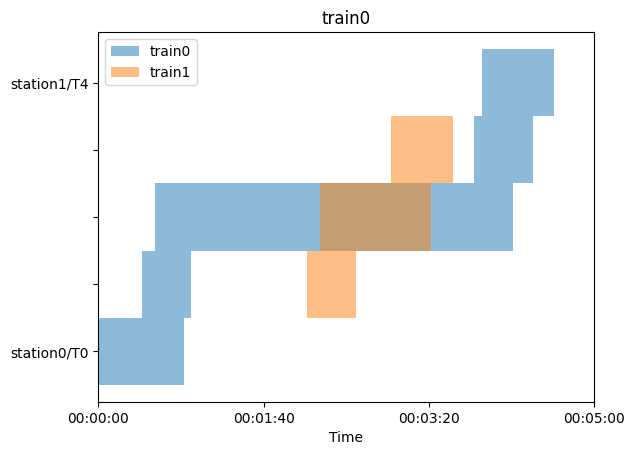

In [25]:
delayed_groot.plot('train0')

In [26]:
delayed_groot.earliest_conflict()

('train0', 'train1', 'D2<->D3', 34.36402894863922)

In [30]:
delayed_groot.train_zones('train1')

['station0/T1', 'CVG', 'D2<->D3', 'DVG', 'station1/T5']

<Axes: xlabel='Time'>

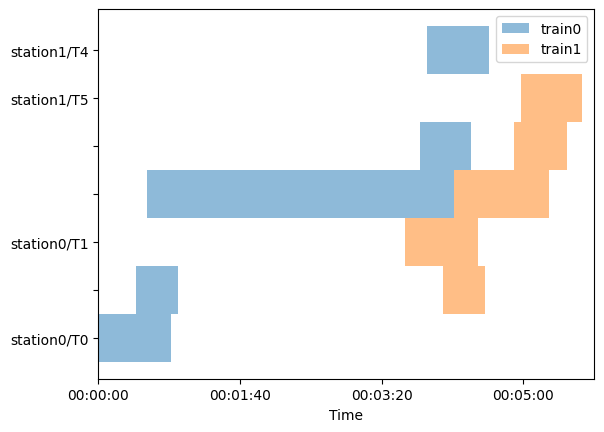

In [35]:
modified_groot = delayed_groot.make_train_wait('train1','train0','station0/T1','D2<->D3')
modified_groot.plot()

In [39]:
from pyosrd.groot.delays_chart import plot_groot_delays

plot_groot_delays(modified_groot, groot, all_trains=False)